In [105]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

In [106]:
stage = "river"

### Reading and compacting dfs

In [107]:
compact = True

In [108]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
for file in os.listdir('dfs'):
    if file.endswith('.parquet'):
        read.append(file)
        df = pd.read_parquet(f"dfs/{file}")
        dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

if compact and len(dfs) > 0:
    print("Compacintg dfs")
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = 'dfs/trash'
    for f in read:
        os.rename(f'dfs/{f}', f'{trash}/{f}')

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f'dfs/compacted_{timestamp}.parquet')

raw_df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size,stage
0,0.000258,0.000689,0.000139,0.001432,0.001087,0.001251,0.001169,0.000402,0.000296,0.000565,...,469,824,1006,1361,True,True,True,2185,3856,river
1,0.001463,0.000636,0.000305,0.001215,0.000938,0.000006,0.000819,0.000180,0.000802,0.000640,...,293,672,581,960,True,True,True,1632,2440,river
2,0.000138,0.000387,0.000071,0.000769,0.000044,0.000409,0.001373,0.000678,0.000638,0.000478,...,27,184,51,208,True,True,True,392,1427,river
3,0.001289,0.000030,0.000777,0.000985,0.000094,0.000627,0.001310,0.001371,0.001411,0.000649,...,248,555,597,904,True,True,True,1459,2455,river
4,0.001238,0.000332,0.000681,0.001456,0.000570,0.000003,0.001478,0.001343,0.000666,0.000491,...,38,471,88,521,True,True,True,992,1310,river
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,0.000989,0.000347,0.000547,0.000997,0.000916,0.000927,0.000512,0.000767,0.001307,0.000533,...,9,155,171,317,True,True,True,472,933,river
2189,0.000513,0.000670,0.000720,0.000799,0.000191,0.001090,0.001134,0.000594,0.000135,0.001351,...,17,28,24,35,True,True,True,63,1336,river
2190,0.000583,0.001339,0.001078,0.000957,0.000063,0.000990,0.000635,0.000010,0.001291,0.000248,...,674,1098,891,1315,True,True,True,2413,4202,river
2191,0.000596,0.000125,0.001049,0.001512,0.000123,0.000819,0.000776,0.000167,0.000587,0.000241,...,38,66,70,98,True,True,True,164,1014,river


In [193]:
df = raw_df[raw_df["stage"] == stage]
df = df.drop(columns=["stage"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.000258,0.000689,0.000139,0.001432,0.001087,0.001251,0.001169,0.000402,0.000296,0.000565,...,0.0,469,824,1006,1361,True,True,True,2185,3856
1,0.001463,0.000636,0.000305,0.001215,0.000938,0.000006,0.000819,0.000180,0.000802,0.000640,...,0.0,293,672,581,960,True,True,True,1632,2440
2,0.000138,0.000387,0.000071,0.000769,0.000044,0.000409,0.001373,0.000678,0.000638,0.000478,...,0.0,27,184,51,208,True,True,True,392,1427
3,0.001289,0.000030,0.000777,0.000985,0.000094,0.000627,0.001310,0.001371,0.001411,0.000649,...,1.0,248,555,597,904,True,True,True,1459,2455
4,0.001238,0.000332,0.000681,0.001456,0.000570,0.000003,0.001478,0.001343,0.000666,0.000491,...,0.0,38,471,88,521,True,True,True,992,1310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,0.000989,0.000347,0.000547,0.000997,0.000916,0.000927,0.000512,0.000767,0.001307,0.000533,...,0.0,9,155,171,317,True,True,True,472,933
2189,0.000513,0.000670,0.000720,0.000799,0.000191,0.001090,0.001134,0.000594,0.000135,0.001351,...,0.0,17,28,24,35,True,True,True,63,1336
2190,0.000583,0.001339,0.001078,0.000957,0.000063,0.000990,0.000635,0.000010,0.001291,0.000248,...,0.0,674,1098,891,1315,True,True,True,2413,4202
2191,0.000596,0.000125,0.001049,0.001512,0.000123,0.000819,0.000776,0.000167,0.000587,0.000241,...,0.0,38,66,70,98,True,True,True,164,1014


In [194]:
# Show all types of columns:
list(sorted(set(["_".join(col.split("_")[0:2]) for col in df.columns])))

['game_size',
 'opponent_bet',
 'opponent_has',
 'player_bet',
 'player_has',
 'player_turn',
 'pot',
 'prob_O',
 'prob_P',
 'public_card',
 'value_of']

### Preprocessing

In [195]:
# Divide all bets by game_size
bet_columns = [
    "player_bet_in_stage",
    "player_bet_in_game",
    "opponent_bet_in_stage",
    "opponent_bet_in_game",
    "pot",
]

def scale_bets(df):
    df[bet_columns] = df[bet_columns].div(df["game_size"], axis=0)
    return df


scale_bets(df)
df[bet_columns]

,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,pot
0,0.121629,0.213693,0.260892,0.352956,0.566649
1,0.120082,0.275410,0.238115,0.393443,0.668852
2,0.018921,0.128942,0.035739,0.145760,0.274702
3,0.101018,0.226069,0.243177,0.368228,0.594297
4,0.029008,0.359542,0.067176,0.397710,0.757252
...,...,...,...,...,...
2188,0.009646,0.166131,0.183280,0.339764,0.505895
2189,0.012725,0.020958,0.017964,0.026198,0.047156
2190,0.160400,0.261304,0.212042,0.312946,0.574250
2191,0.037475,0.065089,0.069034,0.096647,0.161736


In [196]:
# Scale range features so that the mean becomes 0 and the standard deviation becomes 1
range_columns = [col for col in df.columns if col.startswith("prob_")]
def scale_ranges(df, training_mean, training_sd):
    df[range_columns] = (df[range_columns] - training_mean) / training_sd
    return df

def get_training_range_mean_and_sd(df):
    return df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std()

def revert_range_scaling(df, training_mean, training_sd):
    df[range_columns] = df[range_columns] * training_sd + training_mean
    return df

mean_training_range_val, sd_training_range_val = get_training_range_mean_and_sd(df)
scale_ranges(df, mean_training_range_val, sd_training_range_val)
print("Original mean and sd of range features:")
print(mean_training_range_val, sd_training_range_val)
print("Mean and sd of range features after scaling:")
print(df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std())
df[range_columns]

Original mean and sd of range features:
0.000754147812971341 0.000435060949645654
Mean and sd of range features after scaling:
3.167498491976293e-15 0.9999999999999998


,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,prob_O_has_hand_1316,prob_O_has_hand_1317,prob_O_has_hand_1318,prob_O_has_hand_1319,prob_O_has_hand_1320,prob_O_has_hand_1321,prob_O_has_hand_1322,prob_O_has_hand_1323,prob_O_has_hand_1324,prob_O_has_hand_1325
0,-1.141350,-0.150709,-1.414016,1.557783,0.765016,1.143101,0.952422,-0.808558,-1.052081,-0.435660,...,0.147569,-1.314718,-0.005380,1.487532,-1.662110,-0.131012,-0.319253,0.155636,1.334305,-1.332950
1,1.628300,-0.271420,-1.031492,1.060220,0.421781,-1.718821,0.147978,-1.320432,0.109051,-0.262927,...,1.294025,-1.350366,-0.625789,-0.384006,-0.929906,0.484419,-1.438970,-0.797289,-1.349381,0.173572
2,-1.417027,-0.842849,-1.570609,0.034873,-1.632749,-0.792251,1.422941,-0.175892,-0.267937,-0.634302,...,1.151813,0.527924,-0.799076,1.123725,-1.339590,0.044584,1.576933,0.250850,0.357945,0.415927
3,1.229813,-1.664199,0.053396,0.531060,-1.516311,-0.292107,1.276957,1.418030,1.510041,-0.240873,...,0.946885,0.355049,1.407295,-1.727528,-0.991113,0.769447,0.832110,1.264144,1.570282,0.859423
4,1.112922,-0.971247,-0.167322,1.614236,-0.422804,-1.726580,1.663251,1.354434,-0.201883,-0.604163,...,1.601756,1.151095,0.513395,-0.781822,-0.408897,1.090821,-0.914711,1.489816,1.133373,0.258669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,0.539922,-0.934969,-0.475886,0.557536,0.372541,0.397975,-0.556758,0.030010,1.269640,-0.508957,...,-1.067149,0.351837,1.284277,-0.012143,-0.609615,0.581359,-0.862538,-1.076739,-1.236288,1.645223
2189,-0.554774,-0.193053,-0.078991,0.103126,-1.293471,0.771432,0.873066,-0.368230,-1.422122,1.372288,...,-1.396461,-0.365198,1.672698,-0.732612,1.129033,-1.151489,-0.073321,-1.566538,-0.139702,-1.418396
2190,-0.392713,1.343666,0.743359,0.466693,-1.588139,0.542851,-0.273523,-1.709547,1.232942,-1.162516,...,-0.787936,0.413468,0.085693,-1.203190,1.514482,-1.402409,-0.332300,1.390041,-0.758264,1.290081
2191,-0.363989,-1.445607,0.678602,1.741887,-1.450054,0.148510,0.050840,-1.348749,-0.383654,-1.179522,...,1.454176,1.736813,1.475133,1.156565,0.019204,-0.005472,0.963725,0.789420,1.163100,-0.818868


In [205]:
# Scale node values (target variable) so that the mean becomes 0 and the standard deviation becomes 1
value_columns = [col for col in df.columns if col.startswith("value_")]


def scale_values(df, training_mean, training_sd):
    df[value_columns] = (df[value_columns] - training_mean) / training_sd
    return df


def get_training_target_mean_and_sd(df):
    return df[value_columns].to_numpy().mean(), df[value_columns].to_numpy().std()


def revert_value_scaling(arr: np.array, training_mean, training_sd):
    return arr * training_sd + training_mean


mean_training_value_val, sd_training_value_val = get_training_target_mean_and_sd(df)
orig_values = df[value_columns]
scale_values(df, mean_training_value_val, sd_training_value_val)
print("Original mean and sd of values:")
print(orig_values.to_numpy().mean())
print(orig_values.to_numpy().std())
print("New mean and sd of values:")
print(df[value_columns].to_numpy().mean())
print(df[value_columns].to_numpy().std())
# Check revert function
assert np.allclose(
    revert_value_scaling(df, mean_training_value_val, sd_training_value_val)[
        value_columns
    ].to_numpy(),
    orig_values.to_numpy(),
)
df[value_columns]

Original mean and sd of values:
-21591.99125495955
1362259.4822441714
New mean and sd of values:
-2.932170999705357e-18
1.0000000000000007


,value_of_hand_0,value_of_hand_1,value_of_hand_2,value_of_hand_3,value_of_hand_4,value_of_hand_5,value_of_hand_6,value_of_hand_7,value_of_hand_8,value_of_hand_9,...,value_of_hand_1316,value_of_hand_1317,value_of_hand_1318,value_of_hand_1319,value_of_hand_1320,value_of_hand_1321,value_of_hand_1322,value_of_hand_1323,value_of_hand_1324,value_of_hand_1325
0,0.015850,0.015912,0.015908,0.015902,0.015817,0.015812,0.015893,0.015882,0.015868,0.015850,...,0.015859,0.015806,0.015801,0.015829,0.015806,0.015801,0.015828,0.015798,0.015805,0.015801
1,0.015877,0.015877,0.015877,0.015849,0.015871,0.015866,0.015838,0.015835,0.015850,0.015826,...,0.015829,0.015826,0.015829,0.015834,0.015826,0.015829,0.015832,0.015826,0.015826,0.015830
2,0.015891,0.015891,0.015825,0.015886,0.015880,0.015821,0.015872,0.015864,0.015853,0.015818,...,0.015813,0.015850,0.015850,0.015813,0.015850,0.015850,0.015813,0.015850,0.015850,0.015850
3,0.015879,0.015879,0.015880,0.015832,0.015872,0.015866,0.015858,0.015848,0.015828,0.015850,...,0.015828,0.015824,0.015823,0.015850,0.015823,0.015828,0.015850,0.015823,0.015850,0.015850
4,0.015930,0.015850,0.015928,0.015809,0.015802,0.015923,0.015915,0.015796,0.015904,0.015887,...,0.015794,0.015793,0.015793,0.015781,0.015877,0.015857,0.015787,0.015854,0.015786,0.015786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,0.015820,0.015792,0.015850,0.015819,0.015819,0.015818,0.015790,0.015789,0.015817,0.015817,...,0.015794,0.015794,0.015793,0.015793,0.015884,0.015866,0.015827,0.015863,0.015825,0.015823
2189,0.015858,0.015858,0.015859,0.015850,0.015844,0.015857,0.015843,0.015855,0.015854,0.015851,...,0.015852,0.015850,0.015842,0.015846,0.015848,0.015842,0.015846,0.015842,0.015845,0.015842
2190,0.015801,0.015850,0.015803,0.015802,0.015802,0.015803,0.015803,0.015803,0.015803,0.015803,...,0.015862,0.015827,0.015816,0.015809,0.015825,0.015816,0.015809,0.015816,0.015809,0.015808
2191,0.015850,0.015835,0.015835,0.015835,0.015834,0.015835,0.015835,0.015827,0.015834,0.015834,...,0.015827,0.015827,0.015827,0.015827,0.015854,0.015840,0.015837,0.015840,0.015837,0.015837


In [206]:
orig_values

,value_of_hand_0,value_of_hand_1,value_of_hand_2,value_of_hand_3,value_of_hand_4,value_of_hand_5,value_of_hand_6,value_of_hand_7,value_of_hand_8,value_of_hand_9,...,value_of_hand_1316,value_of_hand_1317,value_of_hand_1318,value_of_hand_1319,value_of_hand_1320,value_of_hand_1321,value_of_hand_1322,value_of_hand_1323,value_of_hand_1324,value_of_hand_1325
0,0.000000,84.066166,79.347758,71.215775,-45.239945,-51.649534,57.865807,42.990186,24.654487,0.000000,...,12.496475,-60.696167,-66.891843,-29.242511,-60.687703,-67.026336,-30.810592,-71.690936,-61.236282,-67.073719
1,36.031189,36.106998,36.105452,-1.189621,28.343873,21.226889,-17.156277,-20.874782,0.000000,-33.450226,...,-28.692132,-32.846523,-29.379582,-21.965858,-32.702218,-29.353473,-24.796553,-32.670077,-33.119480,-27.027966
2,55.155856,55.339227,-34.528591,48.635710,40.321067,-39.800084,30.050739,18.409045,4.353453,-44.292080,...,-50.761131,0.000000,0.000000,-50.940481,0.000000,0.000000,-50.518522,0.000000,0.000000,0.000000
3,39.923992,39.601662,40.183204,-24.751484,30.377654,21.619694,10.509842,-2.398683,-29.598557,0.000000,...,-29.919079,-36.098941,-37.452696,0.000000,-37.222696,-29.819865,0.000000,-36.312486,0.000000,0.000000
4,108.664142,0.000000,105.965810,-56.063753,-65.520481,98.937126,88.654305,-73.819858,73.028729,49.716744,...,-76.732674,-77.573181,-78.043083,-93.662315,36.562174,9.990744,-85.537351,5.703450,-86.946328,-87.449730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,-41.640478,-79.156663,0.000000,-42.118870,-42.890070,-43.604935,-81.555440,-82.617263,-44.629098,-45.087348,...,-76.751636,-76.959790,-77.926741,-77.701221,46.616641,21.175601,-31.094145,17.816064,-33.979677,-36.491664
2189,11.282759,11.330156,11.432388,0.000000,-8.443192,8.866072,-9.504274,6.927498,4.744660,1.413945,...,3.068361,-0.102987,-10.752616,-6.137572,-2.586518,-10.794259,-6.295009,-10.850370,-6.456378,-10.872545
2190,-66.349504,0.000000,-64.626661,-64.965570,-65.489388,-64.703567,-64.589786,-64.582699,-64.413267,-64.581024,...,15.542178,-32.003687,-46.413898,-55.964131,-33.723244,-46.399278,-55.897841,-47.149452,-56.484719,-56.975077
2191,0.000000,-20.965836,-21.262920,-21.211323,-21.340958,-21.046693,-20.968291,-31.962870,-21.926084,-22.219297,...,-31.473509,-31.696416,-31.709612,-31.875163,5.705499,-13.194292,-17.946725,-14.179295,-18.425806,-18.560541


In [198]:
# Make boolean features 0 or 1
def encode_bools(df):
    bool_columns = [
        "player_turn",
        "player_has_bet",
        "opponent_has_bet",
    ]
    df[bool_columns] = df[bool_columns].astype(int)
    return df

df = encode_bools(df)
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,-1.141350,-0.150709,-1.414016,1.557783,0.765016,1.143101,0.952422,-0.808558,-1.052081,-0.435660,...,0.0,0.121629,0.213693,0.260892,0.352956,1,1,1,0.566649,3856
1,1.628300,-0.271420,-1.031492,1.060220,0.421781,-1.718821,0.147978,-1.320432,0.109051,-0.262927,...,0.0,0.120082,0.275410,0.238115,0.393443,1,1,1,0.668852,2440
2,-1.417027,-0.842849,-1.570609,0.034873,-1.632749,-0.792251,1.422941,-0.175892,-0.267937,-0.634302,...,0.0,0.018921,0.128942,0.035739,0.145760,1,1,1,0.274702,1427
3,1.229813,-1.664199,0.053396,0.531060,-1.516311,-0.292107,1.276957,1.418030,1.510041,-0.240873,...,1.0,0.101018,0.226069,0.243177,0.368228,1,1,1,0.594297,2455
4,1.112922,-0.971247,-0.167322,1.614236,-0.422804,-1.726580,1.663251,1.354434,-0.201883,-0.604163,...,0.0,0.029008,0.359542,0.067176,0.397710,1,1,1,0.757252,1310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,0.539922,-0.934969,-0.475886,0.557536,0.372541,0.397975,-0.556758,0.030010,1.269640,-0.508957,...,0.0,0.009646,0.166131,0.183280,0.339764,1,1,1,0.505895,933
2189,-0.554774,-0.193053,-0.078991,0.103126,-1.293471,0.771432,0.873066,-0.368230,-1.422122,1.372288,...,0.0,0.012725,0.020958,0.017964,0.026198,1,1,1,0.047156,1336
2190,-0.392713,1.343666,0.743359,0.466693,-1.588139,0.542851,-0.273523,-1.709547,1.232942,-1.162516,...,0.0,0.160400,0.261304,0.212042,0.312946,1,1,1,0.574250,4202
2191,-0.363989,-1.445607,0.678602,1.741887,-1.450054,0.148510,0.050840,-1.348749,-0.383654,-1.179522,...,0.0,0.037475,0.065089,0.069034,0.096647,1,1,1,0.161736,1014


In [199]:
# Drop game_size column
df = df.drop(columns=["game_size"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
0,-1.141350,-0.150709,-1.414016,1.557783,0.765016,1.143101,0.952422,-0.808558,-1.052081,-0.435660,...,0.0,0.0,0.121629,0.213693,0.260892,0.352956,1,1,1,0.566649
1,1.628300,-0.271420,-1.031492,1.060220,0.421781,-1.718821,0.147978,-1.320432,0.109051,-0.262927,...,0.0,0.0,0.120082,0.275410,0.238115,0.393443,1,1,1,0.668852
2,-1.417027,-0.842849,-1.570609,0.034873,-1.632749,-0.792251,1.422941,-0.175892,-0.267937,-0.634302,...,1.0,0.0,0.018921,0.128942,0.035739,0.145760,1,1,1,0.274702
3,1.229813,-1.664199,0.053396,0.531060,-1.516311,-0.292107,1.276957,1.418030,1.510041,-0.240873,...,0.0,1.0,0.101018,0.226069,0.243177,0.368228,1,1,1,0.594297
4,1.112922,-0.971247,-0.167322,1.614236,-0.422804,-1.726580,1.663251,1.354434,-0.201883,-0.604163,...,0.0,0.0,0.029008,0.359542,0.067176,0.397710,1,1,1,0.757252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,0.539922,-0.934969,-0.475886,0.557536,0.372541,0.397975,-0.556758,0.030010,1.269640,-0.508957,...,0.0,0.0,0.009646,0.166131,0.183280,0.339764,1,1,1,0.505895
2189,-0.554774,-0.193053,-0.078991,0.103126,-1.293471,0.771432,0.873066,-0.368230,-1.422122,1.372288,...,0.0,0.0,0.012725,0.020958,0.017964,0.026198,1,1,1,0.047156
2190,-0.392713,1.343666,0.743359,0.466693,-1.588139,0.542851,-0.273523,-1.709547,1.232942,-1.162516,...,0.0,0.0,0.160400,0.261304,0.212042,0.312946,1,1,1,0.574250
2191,-0.363989,-1.445607,0.678602,1.741887,-1.450054,0.148510,0.050840,-1.348749,-0.383654,-1.179522,...,0.0,0.0,0.037475,0.065089,0.069034,0.096647,1,1,1,0.161736


### Data validation

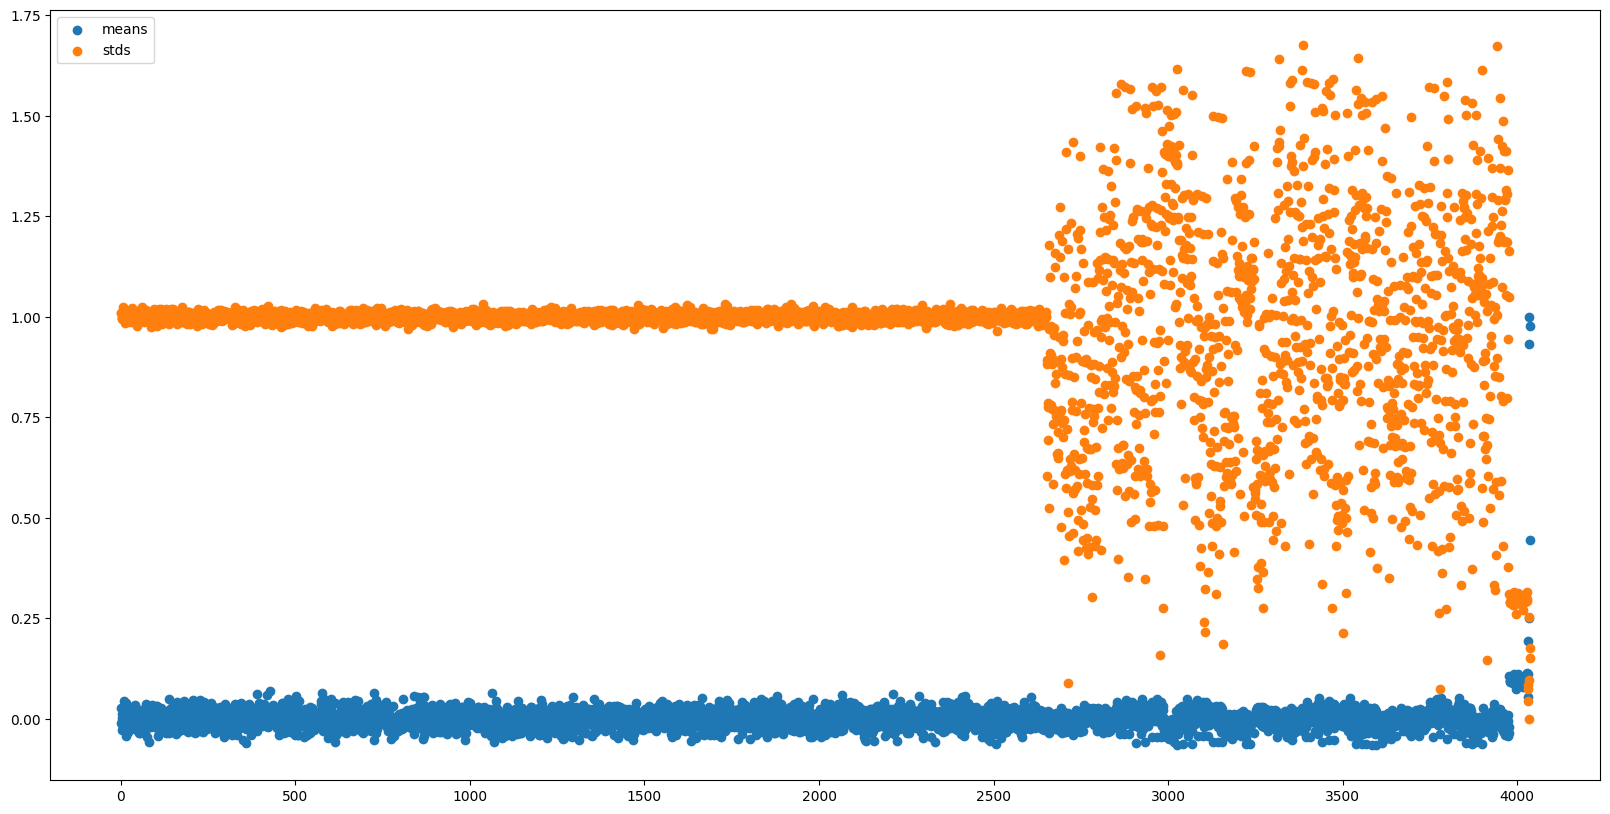

In [207]:
# Check that values are in correct range
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(range(df.mean().size), df.mean(), label="means")
plt.scatter(range(df.std().size), df.std(), label="stds")
plt.legend()
plt.show()

In [218]:
raw_df[value_columns].describe()

,value_of_hand_0,value_of_hand_1,value_of_hand_2,value_of_hand_3,value_of_hand_4,value_of_hand_5,value_of_hand_6,value_of_hand_7,value_of_hand_8,value_of_hand_9,...,value_of_hand_1316,value_of_hand_1317,value_of_hand_1318,value_of_hand_1319,value_of_hand_1320,value_of_hand_1321,value_of_hand_1322,value_of_hand_1323,value_of_hand_1324,value_of_hand_1325
count,2.193000e+03,2.193000e+03,2.193000e+03,2.193000e+03,2.193000e+03,2.193000e+03,2.193000e+03,2.193000e+03,2.193000e+03,2.193000e+03,...,2.193000e+03,2.193000e+03,2.193000e+03,2.193000e+03,2.193000e+03,2.193000e+03,2.193000e+03,2.193000e+03,2.193000e+03,2.193000e+03
mean,-2.197095e+04,-1.501733e+04,-1.355108e+04,-9.454775e+02,-2.585857e+04,4.231663e+03,-7.137950e+04,-3.661544e+04,2.477034e+03,-5.493199e+03,...,-3.857964e+04,-2.754073e+04,-2.901648e+04,-5.535823e+04,-1.509553e+04,-2.784681e+04,-7.970699e+04,-9.295622e+03,-6.860331e+04,-5.124700e+04
std,8.226364e+05,1.214158e+06,1.201702e+06,9.442865e+05,1.069973e+06,1.057632e+06,1.605792e+06,1.320884e+06,7.122600e+05,1.210126e+06,...,1.790933e+06,1.435365e+06,1.087809e+06,1.615329e+06,1.778270e+06,1.284882e+06,1.857449e+06,5.123243e+05,1.583504e+06,1.428989e+06
min,-3.653258e+07,-3.585481e+07,-3.427417e+07,-3.578095e+07,-3.545698e+07,-3.623196e+07,-5.331246e+07,-4.133456e+07,-2.215559e+07,-3.786962e+07,...,-5.416435e+07,-4.501553e+07,-4.621715e+07,-5.882514e+07,-5.490876e+07,-5.554382e+07,-5.540088e+07,-2.096955e+07,-5.394047e+07,-5.496345e+07
25%,-2.662750e+01,-2.820572e+01,-2.924026e+01,-3.041435e+01,-2.938966e+01,-3.112701e+01,-3.202894e+01,-3.292117e+01,-3.421475e+01,-3.754473e+01,...,-4.419325e+01,-4.465426e+01,-4.777594e+01,-5.092287e+01,-4.539113e+01,-4.908681e+01,-5.143724e+01,-5.047684e+01,-5.085553e+01,-5.337321e+01
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-5.657161e+00,-1.496042e+01,-1.969564e+01,-2.490655e+01,-1.505473e+01,-1.992649e+01,-2.487780e+01,-2.087100e+01,-2.482587e+01,-2.581853e+01
75%,3.847117e+01,3.518797e+01,3.681087e+01,3.489507e+01,3.466077e+01,2.710105e+01,2.350178e+01,1.908902e+01,1.538308e+01,5.481476e+00,...,4.142609e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.881165e+05,3.645653e+07,3.013133e+07,2.075276e+07,2.105558e+07,2.694608e+07,2.920861e+06,1.954093e+07,2.107238e+07,2.716300e+07,...,2.041960e+07,2.862441e+07,5.539893e+06,8.061319e+06,4.058791e+07,1.069879e+07,5.741504e+05,1.021143e+07,2.214020e+06,2.915253e+06


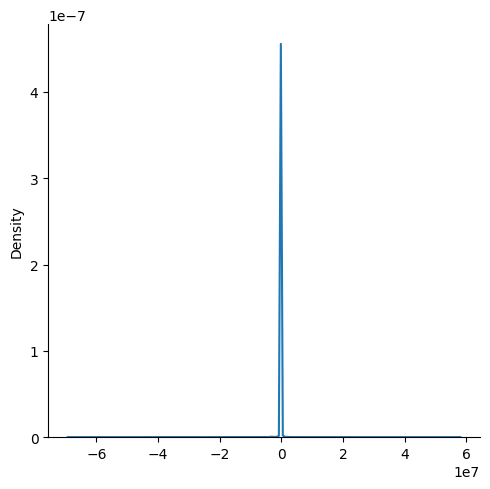

In [217]:
# Plot distribution of output values in a bell curve
from seaborn import displot

displot(raw_df[value_columns].to_numpy().flatten(), kind="kde")
plt.show()


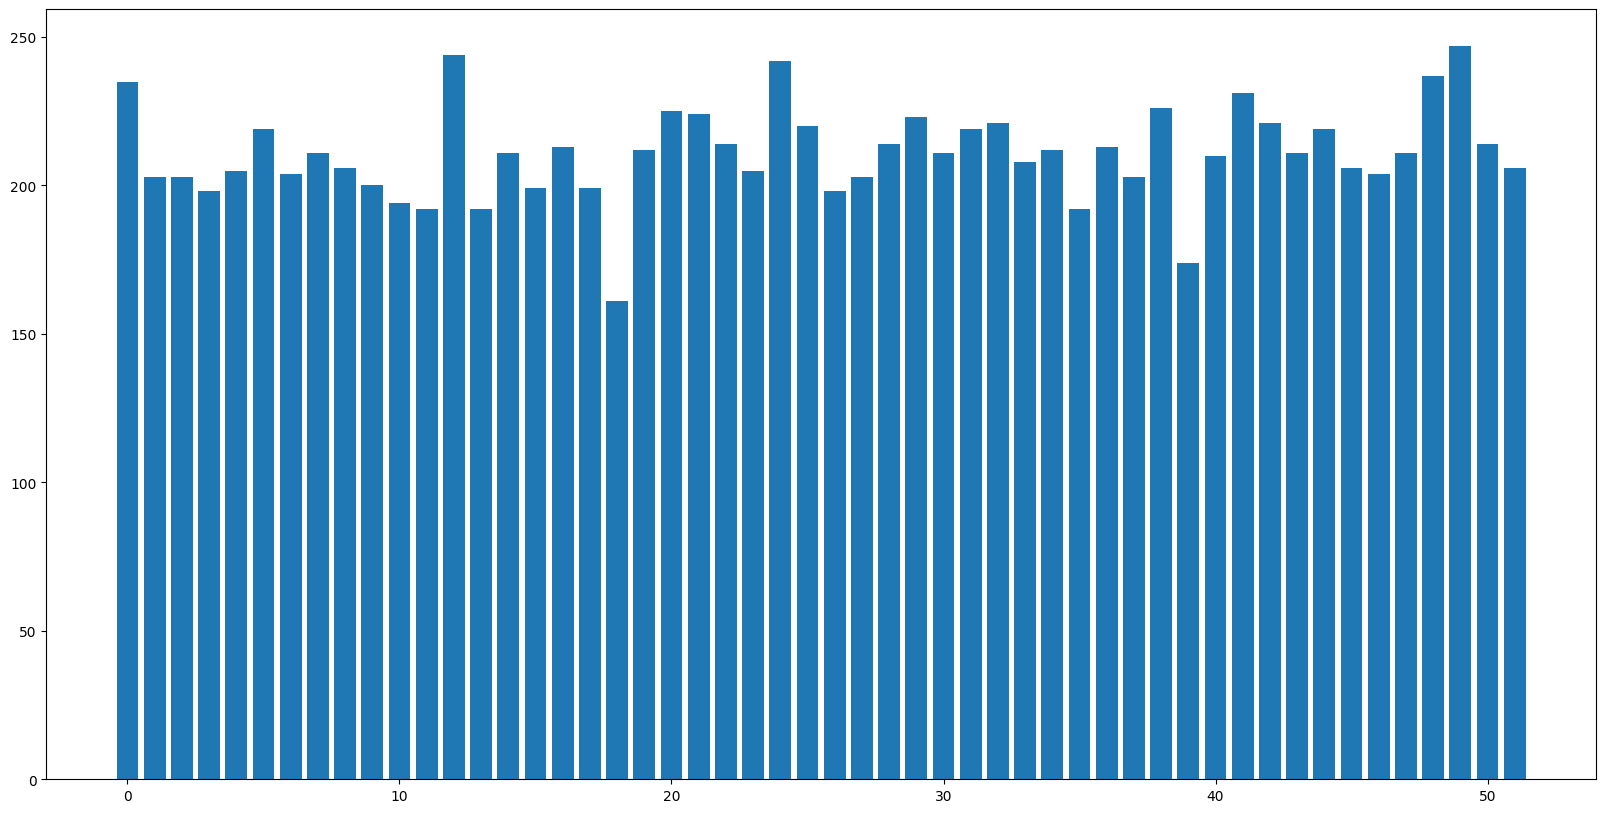

In [136]:
# Check representation of possible public cards
card_cols = [col for col in df.columns if col.startswith("public_card_")]
card_counts = df[card_cols].sum()
fig, ax = plt.subplots(figsize=(20, 10))
plt.bar(range(len(card_counts)), card_counts)
plt.show()

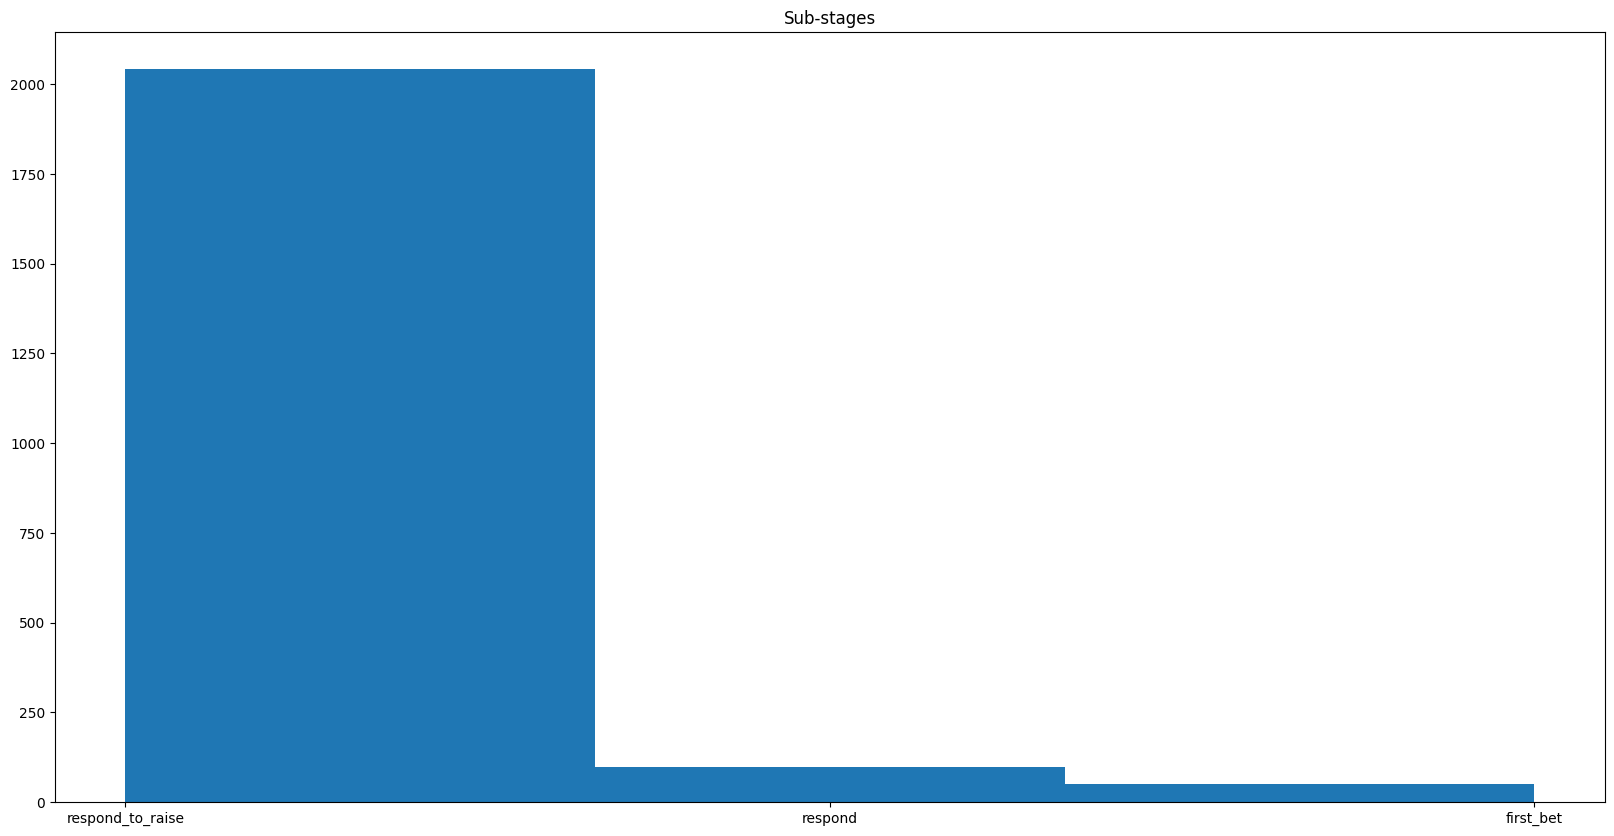

In [137]:
sub_stages = np.where(
    df["player_has_bet"] & df["opponent_has_bet"],
    "respond_to_raise",
    np.where(
        df["opponent_has_bet"],
        "respond",
        "first_bet"
    )
)
fig, ax = plt.subplots(figsize=(20, 10))
plt.hist(sub_stages, bins=3)
plt.title("Sub-stages")
plt.show()

In [138]:
Y_columns = [col for col in df.columns if col.startswith('value_of_hand_')]
X_columns = [col for col in df.columns if col not in Y_columns]
X = df[X_columns].values
Y = df[Y_columns].values
print(X.shape, Y.shape)

(2193, 2712) (2193, 1326)


### Structure for Neural Network

In [141]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [142]:
# Define input layer
input_layer = Input(shape=(X.shape[1],), name="input_layer")

# Define hidden layers
hidden_layer_1 = Dense(128, activation="relu", name="hidden_layer_1")(input_layer)
hidden_layer_2 = Dense(64, activation="relu", name="hidden_layer_2")(hidden_layer_1)
hidden_layer_3 = Dense(32, activation="relu", name="hidden_layer_3")(hidden_layer_2)

# Define value layer for player 1
value_layer_P1 = Dense(Y.shape[1], activation="linear", name="value_layer_P1")(
    hidden_layer_3
)

### Cross validation

In [143]:
# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# This will store the fold results
fold_results = []

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',      # Monitor the validation loss
    patience=5,              # Number of epochs with no improvement after which training will be stopped
    verbose=1,               # To print the message when stopping
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

# Loop over each fold
for i, (train_index, val_index) in enumerate(kf.split(X_train)):
    # Split the data into k-fold training and validation sets
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    Y_train_fold, Y_val_fold = Y_train[train_index], Y_train[val_index]

    print("@@@ FOLD", i, "@@@")
    print("Size of training set:", X_train_fold.shape[0])
    
    # Define and compile the neural network inside the loop to reset weights for each fold
    model = Model(inputs=input_layer, outputs=value_layer_P1)
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    # Train the model
    history = model.fit(
        X_train_fold, Y_train_fold,
        epochs=100,
        validation_data=(X_val_fold, Y_val_fold),
        callbacks=[early_stopping]  # Include the early stopping callback here
    )
    
    # Save the history in fold_results
    fold_results.append(history.history)

@@@ FOLD 0 @@@
Size of training set: 1403
Epoch 1/100
 1/44 [..............................] - ETA: 10s - loss: 0.3348

2024-04-29 16:04:46.240253: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


44/44 [==============================] - 1s 12ms/step - loss: 0.4055 - val_loss: 0.0439
Epoch 2/100
 4/44 [=>............................] - ETA: 0s - loss: 0.0398

2024-04-29 16:04:46.793237: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


44/44 [==============================] - 0s 8ms/step - loss: 0.0202 - val_loss: 0.0125
Epoch 3/100
44/44 [==============================] - 0s 8ms/step - loss: 0.0123 - val_loss: 0.0123
Epoch 4/100
44/44 [==============================] - 0s 7ms/step - loss: 0.0120 - val_loss: 0.0115
Epoch 5/100
44/44 [==============================] - 0s 8ms/step - loss: 0.0115 - val_loss: 0.0113
Epoch 6/100
44/44 [==============================] - 0s 8ms/step - loss: 0.0115 - val_loss: 0.0110
Epoch 7/100
44/44 [==============================] - 0s 9ms/step - loss: 0.0111 - val_loss: 0.0108
Epoch 8/100
44/44 [==============================] - 0s 7ms/step - loss: 0.0107 - val_loss: 0.0106
Epoch 9/100
44/44 [==============================] - 0s 8ms/step - loss: 0.0103 - val_loss: 0.0099
Epoch 10/100
44/44 [==============================] - 0s 8ms/step - loss: 0.0100 - val_loss: 0.0098
Epoch 11/100
44/44 [==============================] - 0s 7ms/step - loss: 0.0096 - val_loss: 0.0095
Epoch 12/100
44/44 [

...

44/44 [==============================] - 0s 7ms/step - loss: 9.8047e-04 - val_loss: 0.0014
Epoch 3/100
44/44 [==============================] - 0s 7ms/step - loss: 8.4677e-04 - val_loss: 0.0013
Epoch 4/100
44/44 [==============================] - 0s 8ms/step - loss: 8.6379e-04 - val_loss: 0.0014
Epoch 5/100
44/44 [==============================] - 0s 7ms/step - loss: 8.7698e-04 - val_loss: 0.0014
Epoch 6/100
44/44 [==============================] - 0s 7ms/step - loss: 8.8332e-04 - val_loss: 0.0013
Epoch 7/100
44/44 [==============================] - 0s 8ms/step - loss: 8.7546e-04 - val_loss: 0.0014
Epoch 8/100
44/44 [==============================] - 0s 7ms/step - loss: 8.5951e-04 - val_loss: 0.0014
Epoch 8: early stopping
@@@ FOLD 4 @@@
Size of training set: 1404
Epoch 1/100
 5/44 [==>...........................] - ETA: 0s - loss: 0.0585     

2024-04-29 16:05:21.793459: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


44/44 [==============================] - 1s 11ms/step - loss: 0.0155 - val_loss: 0.0015
Epoch 2/100
20/44 [============>.................] - ETA: 0s - loss: 0.0014

2024-04-29 16:05:22.325718: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


44/44 [==============================] - 0s 7ms/step - loss: 0.0011 - val_loss: 8.1619e-04
Epoch 3/100
44/44 [==============================] - 0s 7ms/step - loss: 9.8139e-04 - val_loss: 8.4758e-04
Epoch 4/100
44/44 [==============================] - 0s 7ms/step - loss: 9.8615e-04 - val_loss: 8.9269e-04
Epoch 5/100
44/44 [==============================] - 0s 7ms/step - loss: 9.9501e-04 - val_loss: 8.3922e-04
Epoch 6/100
44/44 [==============================] - 0s 9ms/step - loss: 9.8748e-04 - val_loss: 8.0025e-04
Epoch 7/100
44/44 [==============================] - 0s 7ms/step - loss: 9.6408e-04 - val_loss: 8.4439e-04
Epoch 8/100
44/44 [==============================] - 0s 7ms/step - loss: 0.0010 - val_loss: 9.2932e-04
Epoch 9/100
44/44 [==============================] - 0s 8ms/step - loss: 9.8310e-04 - val_loss: 8.3196e-04
Epoch 10/100
44/44 [==============================] - 0s 8ms/step - loss: 0.0010 - val_loss: 8.4086e-04
Epoch 11/100
44/44 [==============================] - 0s 7ms

In [123]:
mse_scores = []

# Evaluate each fold
for fold_history in fold_results:
    val_mse_per_epoch = fold_history['val_loss']
    mse_scores.append(val_mse_per_epoch[-1])  # Take the last epoch MSE

# Calculate the average and standard deviation of the MSE scores across all folds
average_mse = np.mean(mse_scores)
std_dev_mse = np.std(mse_scores)

print(f"Cross-Validation MSE: {average_mse:.4f} (+/- {std_dev_mse:.4f})")
rmse = np.sqrt(average_mse)
rmse_std_dev = np.sqrt(std_dev_mse)
print(f"Cross-Validation RMSE: {rmse:.4f} (+/- {rmse_std_dev:.4f})")
scaled_rmse = revert_value_scaling(rmse, min_training_val, mean_training_val)
scaled_rmse_std_dev = revert_value_scaling(rmse_std_dev, min_training_val, mean_training_val)
print(f"Cross-Validation RMSE (scaled): {scaled_rmse:.4f} (+/- {scaled_rmse_std_dev:.4f})")

Cross-Validation MSE: 0.0006 (+/- 0.0002)
Cross-Validation RMSE: 0.0242 (+/- 0.0139)
Cross-Validation RMSE (scaled): -65739809.5041 (+/- -67161468.5646)


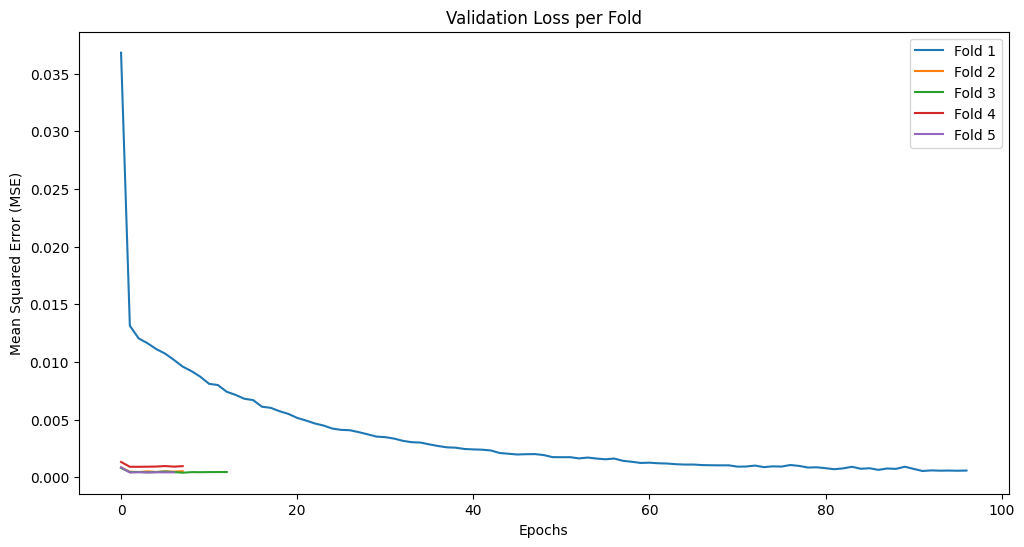

In [124]:
plt.figure(figsize=(12, 6))
for i, fold_history in enumerate(fold_results, 1):
    plt.plot(fold_history['val_loss'], label=f'Fold {i}')

plt.title('Validation Loss per Fold')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

In [126]:
# Find optimal number of epochs
optimal_epochs = []

for result in fold_results:
    val_loss_per_epoch = result['val_loss']
    best_epoch = val_loss_per_epoch.index(min(val_loss_per_epoch))
    optimal_epochs.append(best_epoch)

average_optimal_epoch = np.mean(optimal_epochs)
buffer = 5  # Add a small buffer to avoid underfitting
final_epoch_number = int(average_optimal_epoch + buffer)

print(f"Suggested number of epochs for final training: {final_epoch_number}")

Suggested number of epochs for final training: 25
